# Notebook 4 - Raster data cleaning

In this notebook the final raster layer from the wioverlay analysis in processed and re-classified into catoriezed representing gentrifiation

This notebook processes the output geopakage from the weighted overlay analysis and reclassifies the 6 classes into 3

In [2]:
import os
import geopandas as gpd
import fiona
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:


## Path relative to this notebook
gpkg_path = '../data/raw/vektor_overlay.gpkg'
print(f"GeoPackage path: {gpkg_path}")
print('CWD:', os.getcwd())
print('Exists?', os.path.exists(gpkg_path))
if not os.path.exists(gpkg_path):
    raise FileNotFoundError("GeoPackage not found. Ensure the path '../data/raw/vektor_overlay.gpkg' is correct when running from the notebooks folder.")

layers = []
list_exc = None

## Try listing with fiona
try:
    layers = fiona.listlayers(gpkg_path)
except Exception as e:
    list_exc = e
    print("Fiona listlayers failed:", e)
    
layer_name = layers[0]  
gdf = gpd.read_file(gpkg_path, layer=layer_name)



print("Layers found:", layers)
print("CRS:", gdf.crs)
print("Geometry type(s):", gdf.geom_type.unique())
print("Row count:", len(gdf))

print("Columns:", list(gdf.columns))
print("\nHead:")
print(gdf.head())

GeoPackage path: ../data/raw/vektor_overlay.gpkg
CWD: c:\Users\jonas\Desktop\7_semester\Projekt\Gentrification_model\notebooks
Exists? True
Layers found: ['zonestatistik']
CRS: EPSG:25832
Geometry type(s): ['MultiPolygon']
Row count: 1421
Columns: ['fid_1', 'munic_code', 'id_munic', 'munic_clus', 'Shape_Leng', 'Shape_Area', 'cluster_id', '_count', '_mean', 'diff', 'geometry']

Head:
   fid_1  munic_code  id_munic munic_clus  Shape_Leng  Shape_Area cluster_id  \
0    1.0       101.0       1.0      101_1      1400.0     70000.0      101_1   
1    2.0       101.0       2.0      101_2      1800.0    110000.0      101_2   
2    3.0       101.0       3.0      101_3       800.0     30000.0      101_3   
3    4.0       101.0       4.0      101_4      1000.0     50000.0      101_4   
4    5.0       101.0       5.0      101_5       600.0     20000.0      101_5   

   _count     _mean  diff                                           geometry  
0     7.0  3.620460     0  MULTIPOLYGON (((719400 6178

### plot mean column as a map

The lowest values are most gentrified

CRS: EPSG:25832


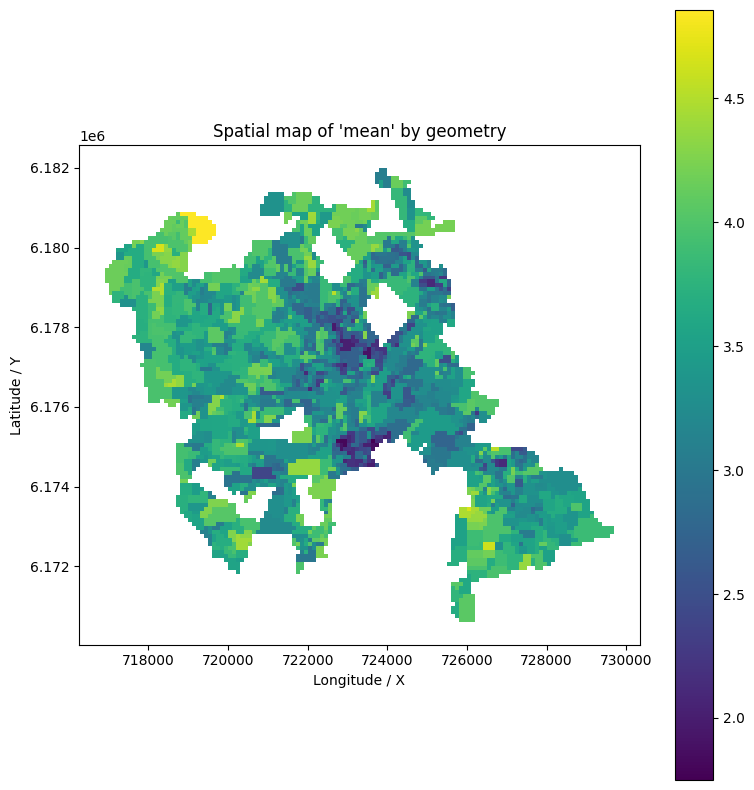

In [4]:
#rename column 'mean_' to 'mean' in gdf
gdf = gdf.rename(columns={'_mean': 'mean'})


# Choose the loaded GeoDataFrame: prefer gdf if present, else gdf_zone
gdf_plot = None
try:
    if isinstance(gdf, gpd.GeoDataFrame) and not gdf.empty:
        gdf_plot = gdf
except NameError:
    pass
try:
    if gdf_plot is None and isinstance(gdf_zone, gpd.GeoDataFrame) and not gdf_zone.empty:
        gdf_plot = gdf_zone
except NameError:
    pass

if gdf_plot is None:
    raise RuntimeError("No GeoDataFrame found. Run the data loading cell first to create 'gdf' or 'gdf_zone'.")

if 'mean' not in gdf_plot.columns:
    raise KeyError("Column 'mean' not found in GeoDataFrame. Check available columns with list(gdf_plot.columns).")

# Optional: ensure a projected CRS for consistent rendering (will plot fine in any CRS)
print('CRS:', gdf_plot.crs)

fig, ax = plt.subplots(figsize=(8, 8))
gdf_plot.plot(column='mean', cmap='viridis', legend=True, ax=ax, missing_kwds={'color': 'lightgrey', 'label': 'No data'})
ax.set_title("Spatial map of 'mean' by geometry")
ax.set_xlabel('Longitude / X')
ax.set_ylabel('Latitude / Y')
plt.tight_layout()
plt.show()

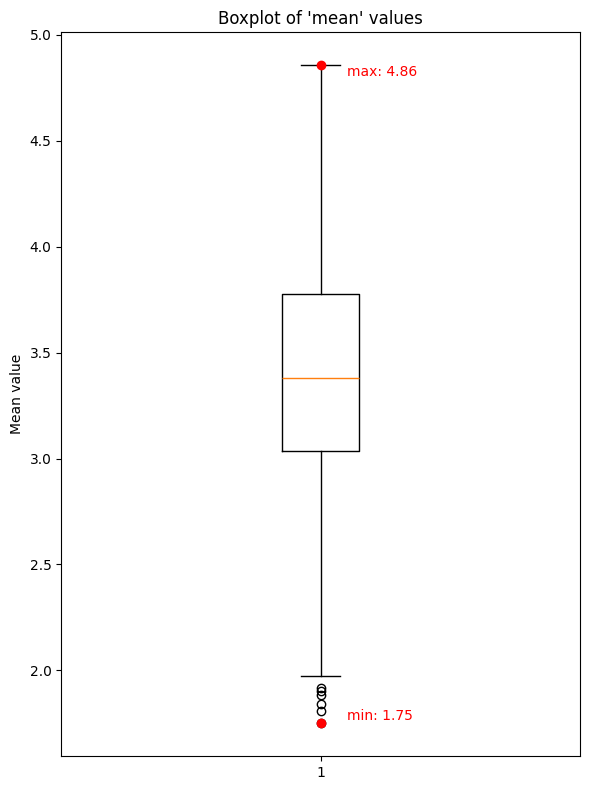

In [5]:
# make a boxplot to show outliers in 'mean' column with min/max annotations
fig, ax = plt.subplots(figsize=(6, 8))
vals = pd.to_numeric(gdf_plot['mean'], errors='coerce').dropna()
if vals.size == 0:
    print("No numeric data in 'mean' to plot.")
else:
    bp = ax.boxplot(vals, vert=True)
    min_v = float(vals.min())
    max_v = float(vals.max())
    # Mark min and max points
    ax.scatter([1, 1], [min_v, max_v], color='red', zorder=3)
    # Annotate values slightly offset to avoid overlap
    ax.text(1.05, min_v, f"min: {min_v:.2f}", va='bottom', ha='left', color='red')
    ax.text(1.05, max_v, f"max: {max_v:.2f}", va='top', ha='left', color='red')
    ax.set_title("Boxplot of 'mean' values")
    ax.set_ylabel('Mean value')
    plt.tight_layout()
    plt.show()


### Categorizing values

mean(mu)=3.3891, std(sigma)=0.5441
Class counts:
 mean_sd_class
(mu-1σ, mu] (slightly low)     519
(mu, mu+1σ] (slightly high)    424
(mu+1σ, mu+2σ] (high)          265
(mu-2σ, mu-1σ] (low)           152
<= mu-2σ (very low)             52
> mu+2σ (very high)              9
Name: count, dtype: int64


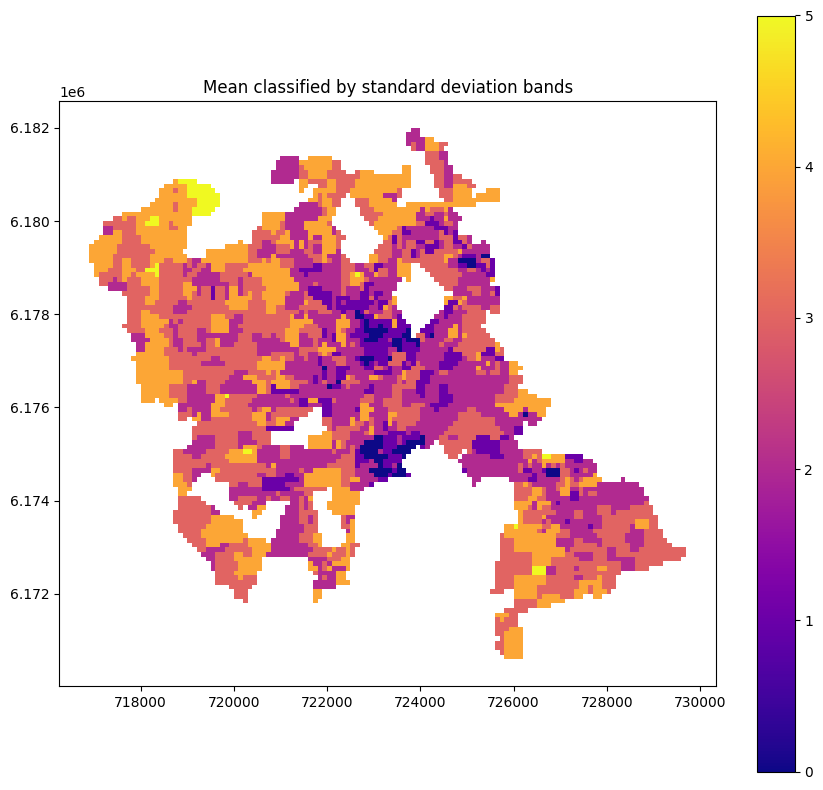

In [6]:
# Classify 'mean' using standard deviation thresholds

# Use existing GeoDataFrame (prefer gdf, else gdf_zone)
gdf_cls = None
try:
    if isinstance(gdf, gpd.GeoDataFrame) and not gdf.empty:
        gdf_cls = gdf
except NameError:
    pass
try:
    if gdf_cls is None and isinstance(gdf_zone, gpd.GeoDataFrame) and not gdf_zone.empty:
        gdf_cls = gdf_zone
except NameError:
    pass

if gdf_cls is None:
    raise RuntimeError("No GeoDataFrame found. Run the data loading cell first to create 'gdf' or 'gdf_zone'.")

# Ensure 'mean' column exists (rename from '_mean' if needed)
if '_mean' in gdf_cls.columns and 'mean' not in gdf_cls.columns:
    gdf_cls = gdf_cls.rename(columns={'_mean': 'mean'})
if 'mean' not in gdf_cls.columns:
    raise KeyError("Column 'mean' not found. Available: " + str(list(gdf_cls.columns)))

# Compute statistics on numeric 'mean'
vals = pd.to_numeric(gdf_cls['mean'], errors='coerce')
mu = vals.mean(skipna=True)
sigma = vals.std(skipna=True)
print(f"mean(mu)={mu:.4f}, std(sigma)={sigma:.4f}")

# Define classification by sigma bands (customizable)
# Bands: <= mu-2σ, (mu-2σ, mu-1σ], (mu-1σ, mu], (mu, mu+1σ], (mu+1σ, mu+2σ], > mu+2σ
bins = [-np.inf, mu - 2*sigma, mu - 1*sigma, mu, mu + 1*sigma, mu + 2*sigma, np.inf]
labels = [
    '<= mu-2σ (very low)',
    '(mu-2σ, mu-1σ] (low)',
    '(mu-1σ, mu] (slightly low)',
    '(mu, mu+1σ] (slightly high)',
    '(mu+1σ, mu+2σ] (high)',
    '> mu+2σ (very high)'
]

gdf_cls['mean_sd_class'] = pd.cut(vals, bins=bins, labels=labels)

# Optional: numeric class index 1..6 for easy plotting
gdf_cls['mean_sd_class_idx'] = pd.cut(vals, bins=bins, labels=False)
print("Class counts:\n", gdf_cls['mean_sd_class'].value_counts(dropna=False))

# Quick map of classes
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 8))
gdf_cls.plot(column='mean_sd_class_idx', cmap='plasma', legend=True, ax=ax, missing_kwds={'color': 'lightgrey', 'label': 'No data'})
ax.set_title("Mean classified by standard deviation bands")
plt.tight_layout()
plt.show()

# Persist (optional)
# gdf_cls[['mean','mean_sd_class','mean_sd_class_idx','geometry']].to_file('../data/interim/mean_sd_class.geojson', driver='GeoJSON')

In [7]:
# turn 6 classes into 3
# Use the classified GeoDataFrame; prefer gdf if present, else gdf_cls
try:
    df_cls = gdf
except NameError:
    try:
        df_cls = gdf_cls
    except NameError:
        raise RuntimeError("No GeoDataFrame found. Run the prior cells to create 'gdf' and classify into 6 classes first.")

# Ensure 6-class classification exists; if not, compute from 'mean'
if 'mean_sd_class_idx' not in df_cls.columns:
    vals = pd.to_numeric(df_cls['mean'], errors='coerce')
    mu = vals.mean(skipna=True)
    sigma = vals.std(skipna=True)
    bins = [-np.inf, mu - 2*sigma, mu - 1*sigma, mu, mu + 1*sigma, mu + 2*sigma, np.inf]
    df_cls['mean_sd_class_idx'] = pd.cut(vals, bins=bins, labels=False)

# Map 6 classes (0..5) to 3 classes (0..2):
#   0,1 -> 0 (low); 2,3 -> 1 (medium); 4,5 -> 2 (high)
map_idx = {0: 0, 1: 0, 2: 1, 3: 1, 4: 2, 5: 2}
idx6 = pd.to_numeric(df_cls['mean_sd_class_idx'], errors='coerce')
df_cls['mean_sd_class3_idx'] = idx6.map(map_idx)

# Add readable labels
label_map = {0: 'Low', 1: 'Medium', 2: 'High'}
df_cls['mean_sd_class3'] = df_cls['mean_sd_class3_idx'].map(label_map)

# Basic sanity output
print("3-class counts:\n", df_cls['mean_sd_class3'].value_counts(dropna=False))

# Ensure downstream export uses 'gdf'
try:
    gdf = df_cls
except Exception:
    pass

# update mean_sd_class column
df_cls ['mean_sd_class_idx'] = df_cls['mean_sd_class3_idx']

3-class counts:
 mean_sd_class3
Medium    943
High      274
Low       204
Name: count, dtype: int64


In [8]:
gdf.head()

,fid_1,munic_code,id_munic,munic_clus,Shape_Leng,Shape_Area,cluster_id,_count,mean,diff,geometry,mean_sd_class,mean_sd_class_idx,mean_sd_class3_idx,mean_sd_class3
0,1.0,101.0,1.0,101_1,1400.0,70000.0,101_1,7.0,3.620460,0,"MULTIPOLYGON (((719400 6178100, 719400 6178200...","(mu, mu+1σ] (slightly high)",1,1,Medium
1,2.0,101.0,2.0,101_2,1800.0,110000.0,101_2,11.0,3.585805,0,"MULTIPOLYGON (((719200 6178100, 719100 6178100...","(mu, mu+1σ] (slightly high)",1,1,Medium
2,3.0,101.0,3.0,101_3,800.0,30000.0,101_3,3.0,3.439353,0,"MULTIPOLYGON (((719400 6177700, 719400 6177800...","(mu, mu+1σ] (slightly high)",1,1,Medium
3,4.0,101.0,4.0,101_4,1000.0,50000.0,101_4,5.0,3.619960,0,"MULTIPOLYGON (((719800 6178200, 719700 6178200...","(mu, mu+1σ] (slightly high)",1,1,Medium
4,5.0,101.0,5.0,101_5,600.0,20000.0,101_5,2.0,3.103799,0,"MULTIPOLYGON (((719900 6177800, 719900 6177900...","(mu-1σ, mu] (slightly low)",1,1,Medium


### Exporting file for later use

In [9]:
# save file 
df_no_geom = gdf.drop(columns='geometry')
df_no_geom.to_csv('../data/interim/STA_data.csv')